In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from generate_colormap import *


from functools import partial
import starsim

from astropy.io import fits


import scipy.io as sio

from scipy.io import readsav

import jdcal as j 
from datetime import date

In [2]:
data = readsav('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/DataSSI-SORCE.sav')
simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/flux_test_mps.txt')
simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/flux_test_phoenix.txt')


In [3]:
data['wavelengths']

array([5.00000e-01, 1.50000e+00, 2.50000e+00, 3.50000e+00, 4.50000e+00,
       5.50000e+00, 6.50000e+00, 7.50000e+00, 8.50000e+00, 9.50000e+00,
       1.05000e+01, 1.15000e+01, 1.25000e+01, 1.35000e+01, 1.45000e+01,
       1.55000e+01, 1.65000e+01, 1.75000e+01, 1.85000e+01, 1.95000e+01,
       2.05000e+01, 2.15000e+01, 2.25000e+01, 2.35000e+01, 2.45000e+01,
       2.55000e+01, 2.65000e+01, 2.75000e+01, 2.85000e+01, 2.95000e+01,
       3.05000e+01, 3.15000e+01, 3.25000e+01, 3.35000e+01, 3.45000e+01,
       3.55000e+01, 3.65000e+01, 3.75000e+01, 3.85000e+01, 3.95000e+01,
       1.15500e+02, 1.16500e+02, 1.17500e+02, 1.18500e+02, 1.19500e+02,
       1.20500e+02, 1.21500e+02, 1.22500e+02, 1.23500e+02, 1.24500e+02,
       1.25500e+02, 1.26500e+02, 1.27500e+02, 1.28500e+02, 1.29500e+02,
       1.30500e+02, 1.31500e+02, 1.32500e+02, 1.33500e+02, 1.34500e+02,
       1.35500e+02, 1.36500e+02, 1.37500e+02, 1.38500e+02, 1.39500e+02,
       1.40500e+02, 1.41500e+02, 1.42500e+02, 1.43500e+02, 1.445

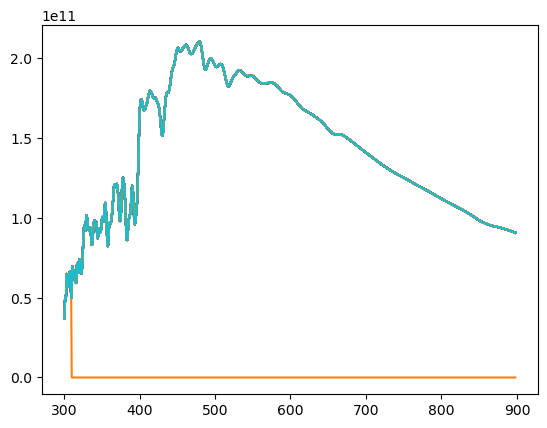

In [4]:
t_tsi = []
t_ssi = []

data_ssi = []
data_tsi = []
wav_idx = (data['wavelengths'] >= 300) & (data['wavelengths'] <= 900)

wav = data['wavelengths'][wav_idx]

start_time = j.gcal2jd(2017,7,1)[1] + 2400000.5
end_time = j.gcal2jd(2017,9,1)[1] + 2400000.5


for i in range(len(data['time_ssi'])):
    if data['time_ssi'][i] >= start_time and data['time_ssi'][i] <= end_time:
        t_ssi.append(j.jd2gcal(2400000.5,data['time_ssi'][i]-2400000.5))

        data_ssi.append(data['ssi'][:,i][wav_idx])

for i in range(len(data['time'])):
    if data['time'][i] >= start_time and data['time'][i] <= end_time:
        t_tsi.append(j.jd2gcal(2400000.5,data['time'][i]-2400000.5))

        data_tsi.append(data['tsi'][i])


data_ssi = np.squeeze(data_ssi)
data_ssi *= 100**2 * 10000000

for i in range(60):
    plt.plot(wav, data_ssi[i])

data_ssi = np.sum(data_ssi / (1e-7 * wav) ,axis=1)

data_tsi = np.squeeze(data_tsi)
data_tsi *= 100**2 * 10000000

# Date de départ
start_date = date(t_tsi[0][0], t_tsi[0][1], t_tsi[0][2])

# Calcul du nombre de jours pour chaque date
days_tsi = [(date(y, m, d) - start_date).days + f for (y, m, d, f) in t_tsi]
days_simu = np.linspace(0, 62, 62)


[ 0.          1.01639344  2.03278689  3.04918033  4.06557377  5.08196721
  6.09836066  7.1147541   8.13114754  9.14754098 10.16393443 11.18032787
 12.19672131 13.21311475 14.2295082  15.24590164 16.26229508 17.27868852
 18.29508197 19.31147541 20.32786885 21.3442623  22.36065574 23.37704918
 24.39344262 25.40983607 26.42622951 27.44262295 28.45901639 29.47540984
 30.49180328 31.50819672 32.52459016 33.54098361 34.55737705 35.57377049
 36.59016393 37.60655738 38.62295082 39.63934426 40.6557377  41.67213115
 42.68852459 43.70491803 44.72131148 45.73770492 46.75409836 47.7704918
 48.78688525 49.80327869 50.81967213 51.83606557 52.85245902 53.86885246
 54.8852459  55.90163934 56.91803279 57.93442623 58.95081967 59.96721311
 60.98360656 62.        ]
[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5, 33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42

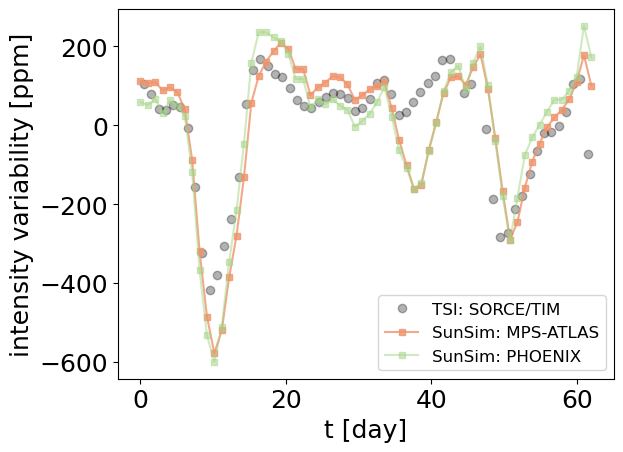

In [5]:
plt.rcParams['font.size'] = 18

plt.plot(days_tsi, 1e6 * data_tsi / np.mean(data_tsi) - 1e6 , 'o', label='TSI: SORCE/TIM', color="#000000", alpha =0.3)
plt.plot(days_simu, 1e6 * simu_mps / np.mean(simu_mps) - 1e6,'s-', markersize=4, linewidth=1.5, label = 'SunSim: MPS-ATLAS', color='#ef946c', alpha=0.8)
plt.plot(days_simu, 1e6 * simu_phoenix / np.mean(simu_phoenix) - 1e6,'s-', markersize=4, linewidth=1.5, label = 'SunSim: PHOENIX', color="#a4d485", alpha=0.5)

plt.legend(fontsize=12)
plt.xlabel('t [day]')
plt.ylabel('intensity variability [ppm]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison.png',  dpi=300, bbox_inches='tight')

print(days_simu)
print(days_tsi)

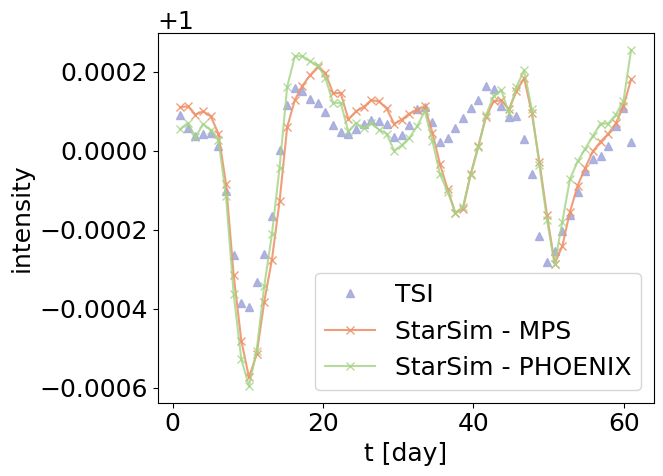

Text(0, 0.5, 'Models')

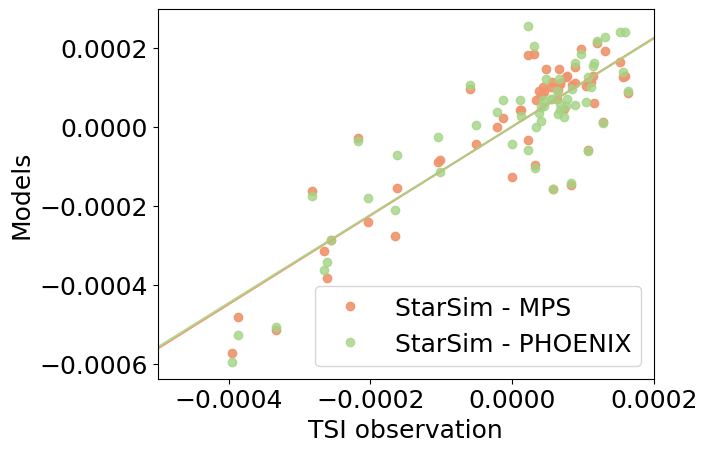

In [6]:
from scipy.interpolate import interp1d
from scipy.stats import linregress

# Example: t_obs, tsi_obs  -- time and TSI from observations
#          t_model, tsi_model  -- time and TSI from a model

# Interpolate model to observation times
interp_func = interp1d(days_tsi, data_tsi, kind='linear', bounds_error=False, fill_value='extrapolate')
days_simu_d = days_simu[1:-1]

tsi_model_interp = interp_func(days_simu_d)



# a4d485

plt.plot(days_simu_d, tsi_model_interp / np.mean(tsi_model_interp)  , '^', label='TSI', color='#a7abdd', alpha =0.9)
plt.plot(days_simu_d, simu_mps[1:-1] / np.mean(simu_mps[1:-1]) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
plt.plot(days_simu_d, simu_phoenix[1:-1] / np.mean(simu_phoenix[1:-1]) ,'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('intensity')
plt.show()

detrended_tsi = (tsi_model_interp - np.mean(tsi_model_interp)) / np.mean(tsi_model_interp)
detrended_mps = (simu_mps[1:-1] - np.mean(simu_mps[1:-1])) / np.mean(simu_mps[1:-1])
detrended_pho = (simu_phoenix[1:-1] - np.mean(simu_phoenix[1:-1])) / np.mean(simu_phoenix[1:-1])
x = np.linspace(-0.0005, 0.0002)

slope_mps, intercept_mps, r_value_mps, p_value_mps, std_err_mps = linregress(detrended_tsi, detrended_mps)
slope_pho, intercept_pho, r_value_pho, p_value_pho, std_err_pho = linregress(detrended_tsi, detrended_pho)


plt.plot(detrended_tsi, detrended_mps ,'o', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
plt.plot(detrended_tsi, detrended_pho ,'o', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
plt.plot(x, slope_mps * x + intercept_mps, color='#ef946c', alpha=0.9)
plt.plot(x, slope_pho * x + intercept_pho, color='#a4d485', alpha=0.8)
plt.xlim(-0.0005, 0.0002)
plt.legend()
plt.xlabel('TSI observation')
plt.ylabel('Models')


In [7]:
print('MPS:', slope_mps, r_value_mps)
print('PHOENIX:', slope_pho, r_value_pho)


MPS: 1.1248082678650504 0.872001416888583
PHOENIX: 1.116789763192405 0.8598456665556379


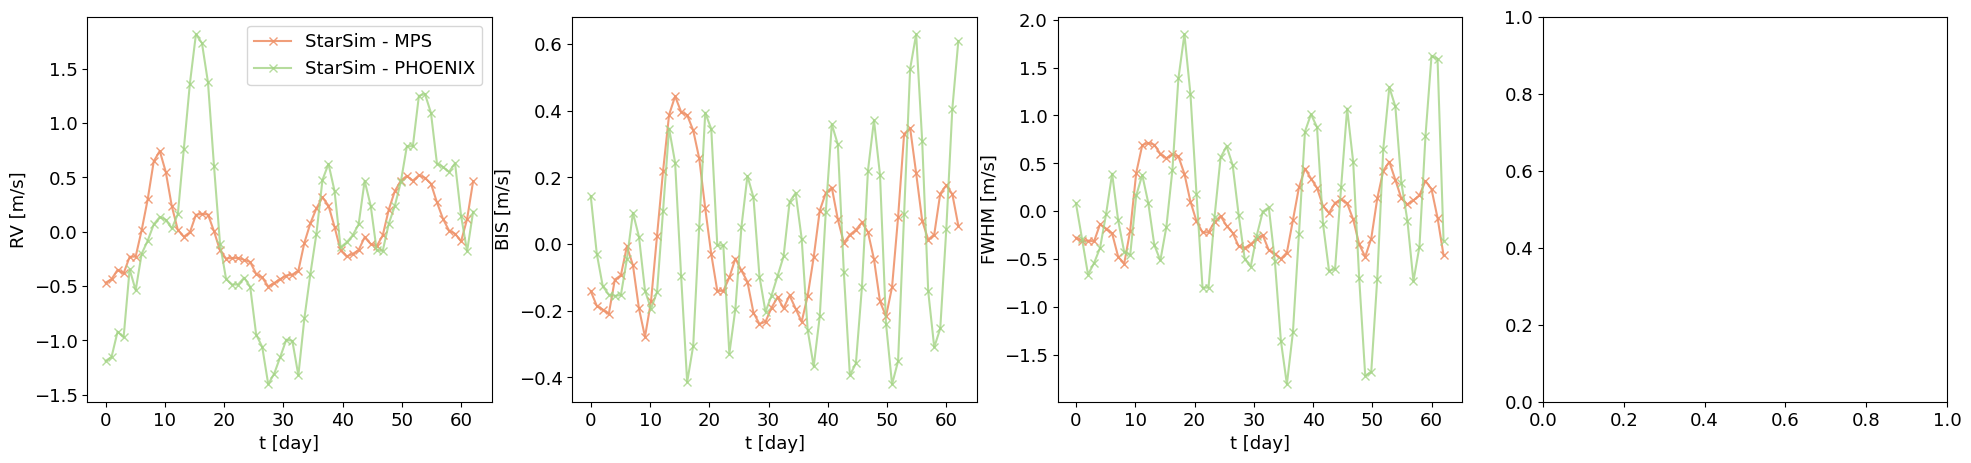

In [8]:
rv_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_mps.txt')
rv_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_phoenix.txt')

bis_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/bis_test_mps.txt')
bis_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/bis_test_phoenix.txt')

fwhm_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/fwhm_test_mps.txt')
fwhm_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/fwhm_test_phoenix.txt')

plt.rcParams['font.size'] = 13


fig, axs = plt.subplots(1,4, figsize=(24,5))


axs[0].plot(days_simu, rv_simu_mps - np.mean(rv_simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
axs[0].plot(days_simu, rv_simu_phoenix - np.mean(rv_simu_phoenix),'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
axs[0].set_xlabel('t [day]')
axs[0].set_ylabel('RV [m/s]')


axs[1].plot(days_simu, bis_simu_mps - np.mean(bis_simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
axs[1].plot(days_simu, bis_simu_phoenix - np.mean(bis_simu_phoenix),'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
axs[1].set_xlabel('t [day]')
axs[1].set_ylabel('BIS [m/s]')


axs[2].plot(days_simu, fwhm_simu_mps - np.mean(fwhm_simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
axs[2].plot(days_simu, fwhm_simu_phoenix - np.mean(fwhm_simu_phoenix),'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
axs[2].set_xlabel('t [day]')
axs[2].set_ylabel('FWHM [m/s]')

axs[0].legend()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec.pdf',  dpi=300, bbox_inches='tight')

plt.show()

[ 0.          1.01639344  2.03278689  3.04918033  4.06557377  5.08196721
  6.09836066  7.1147541   8.13114754  9.14754098 10.16393443 11.18032787
 12.19672131 13.21311475 14.2295082  15.24590164 16.26229508 17.27868852
 18.29508197 19.31147541 20.32786885 21.3442623  22.36065574 23.37704918
 24.39344262 25.40983607 26.42622951 27.44262295 28.45901639 29.47540984
 30.49180328 31.50819672 32.52459016 33.54098361 34.55737705 35.57377049
 36.59016393 37.60655738 38.62295082 39.63934426 40.6557377  41.67213115
 42.68852459 43.70491803 44.72131148 45.73770492 46.75409836 47.7704918
 48.78688525 49.80327869 50.81967213 51.83606557 52.85245902 53.86885246
 54.8852459  55.90163934 56.91803279 57.93442623 58.95081967 59.96721311
 60.98360656 62.        ]
[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5, 33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42

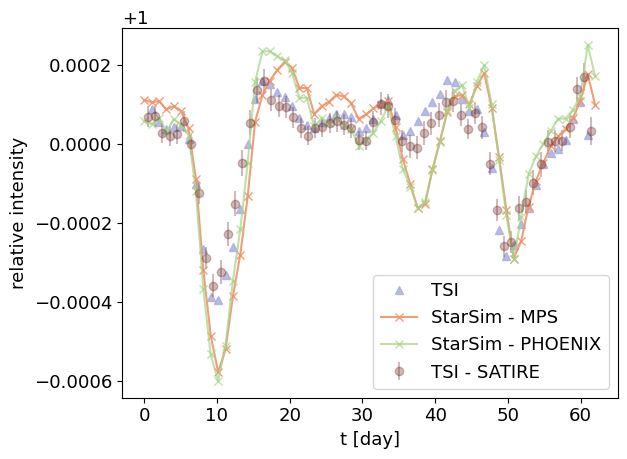

In [9]:
data_tsi_satire = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/SATIRE-S_TSI_latest.txt')


t_satire = []
data_satire = []
err_d = []
err_u = []

for i in range(len(data_tsi_satire[:,0])):
    if data_tsi_satire[i,0] >= start_time and data_tsi_satire[i,0] <= end_time:
        t_satire.append(j.jd2gcal(2400000.5, data_tsi_satire[i,0]-2400000.5))

        data_satire.append(data_tsi_satire[i,1])
        err_d.append(data_tsi_satire[i,2])
        err_u.append(data_tsi_satire[i,2])


days_satire = [(date(y, m, d) - start_date).days + f for (y, m, d, f) in t_satire]



plt.plot(days_simu_d, tsi_model_interp / np.mean(tsi_model_interp)  , '^', label='TSI', color='#a7abdd', alpha =0.8)
plt.errorbar(days_satire, data_satire / np.mean(data_satire)  , yerr=np.array([(np.array(data_satire) - np.array(err_d)) / np.mean(data_satire), (np.array(data_satire) - np.array(err_u)) / np.mean(data_satire)]), label='TSI - SATIRE', marker='o', linestyle='', color='#661F1C', alpha =0.3)
plt.plot(days_simu, simu_mps / np.mean(simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
plt.plot(days_simu, simu_phoenix / np.mean(simu_phoenix) ,'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.7)

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison.png',  dpi=300, bbox_inches='tight')

print(days_simu)
print(days_tsi)

In [10]:
 np.array(err_d) - np.array(data_satire)

array([-0.0367, -0.0361, -0.0341, -0.0338, -0.0341, -0.0364, -0.0377,
       -0.0387, -0.0384, -0.0396, -0.0407, -0.0416, -0.0439, -0.0456,
       -0.0444, -0.044 , -0.0413, -0.0384, -0.0378, -0.0377, -0.0362,
       -0.0348, -0.0337, -0.0346, -0.0346, -0.0352, -0.0356, -0.0354,
       -0.035 , -0.0332, -0.033 , -0.035 , -0.0391, -0.0406, -0.0405,
       -0.039 , -0.0391, -0.0391, -0.0407, -0.0413, -0.0409, -0.0411,
       -0.0401, -0.0369, -0.0349, -0.0371, -0.0386, -0.0388, -0.0378,
       -0.0361, -0.0372, -0.0417, -0.0418, -0.0429, -0.0432, -0.0417,
       -0.0383, -0.0366, -0.0376, -0.0429, -0.0478, -0.0486])